=== Loaded Results ===

                        Precision@5  Recall@5    F1@5
Method                                               
Community-UU (Louvain)       0.4543    0.1582  0.2347
Community-II (Infomap)       0.4613    0.1209  0.1915
SVD+Louvain                  0.6302    0.1776  0.2771
ALS+Louvain                  0.2543    0.1038  0.1474
BM25+Louvain                 0.4101    0.1194  0.1849
SVD+Leiden                   0.6302    0.1776  0.2771
ALS+Leiden                   0.2543    0.1038  0.1474
BM25+Leiden                  0.4090    0.1187  0.1840
SVD+Infomap                  0.6151    0.1625  0.2571
ALS+Infomap                  0.2442    0.0849  0.1260
BM25+Infomap                 0.4090    0.1187  0.1840
SVD+FluidC                   0.6111    0.1622  0.2564
ALS+FluidC                   0.2472    0.0847  0.1262
BM25+FluidC                  0.4050    0.1139  0.1779




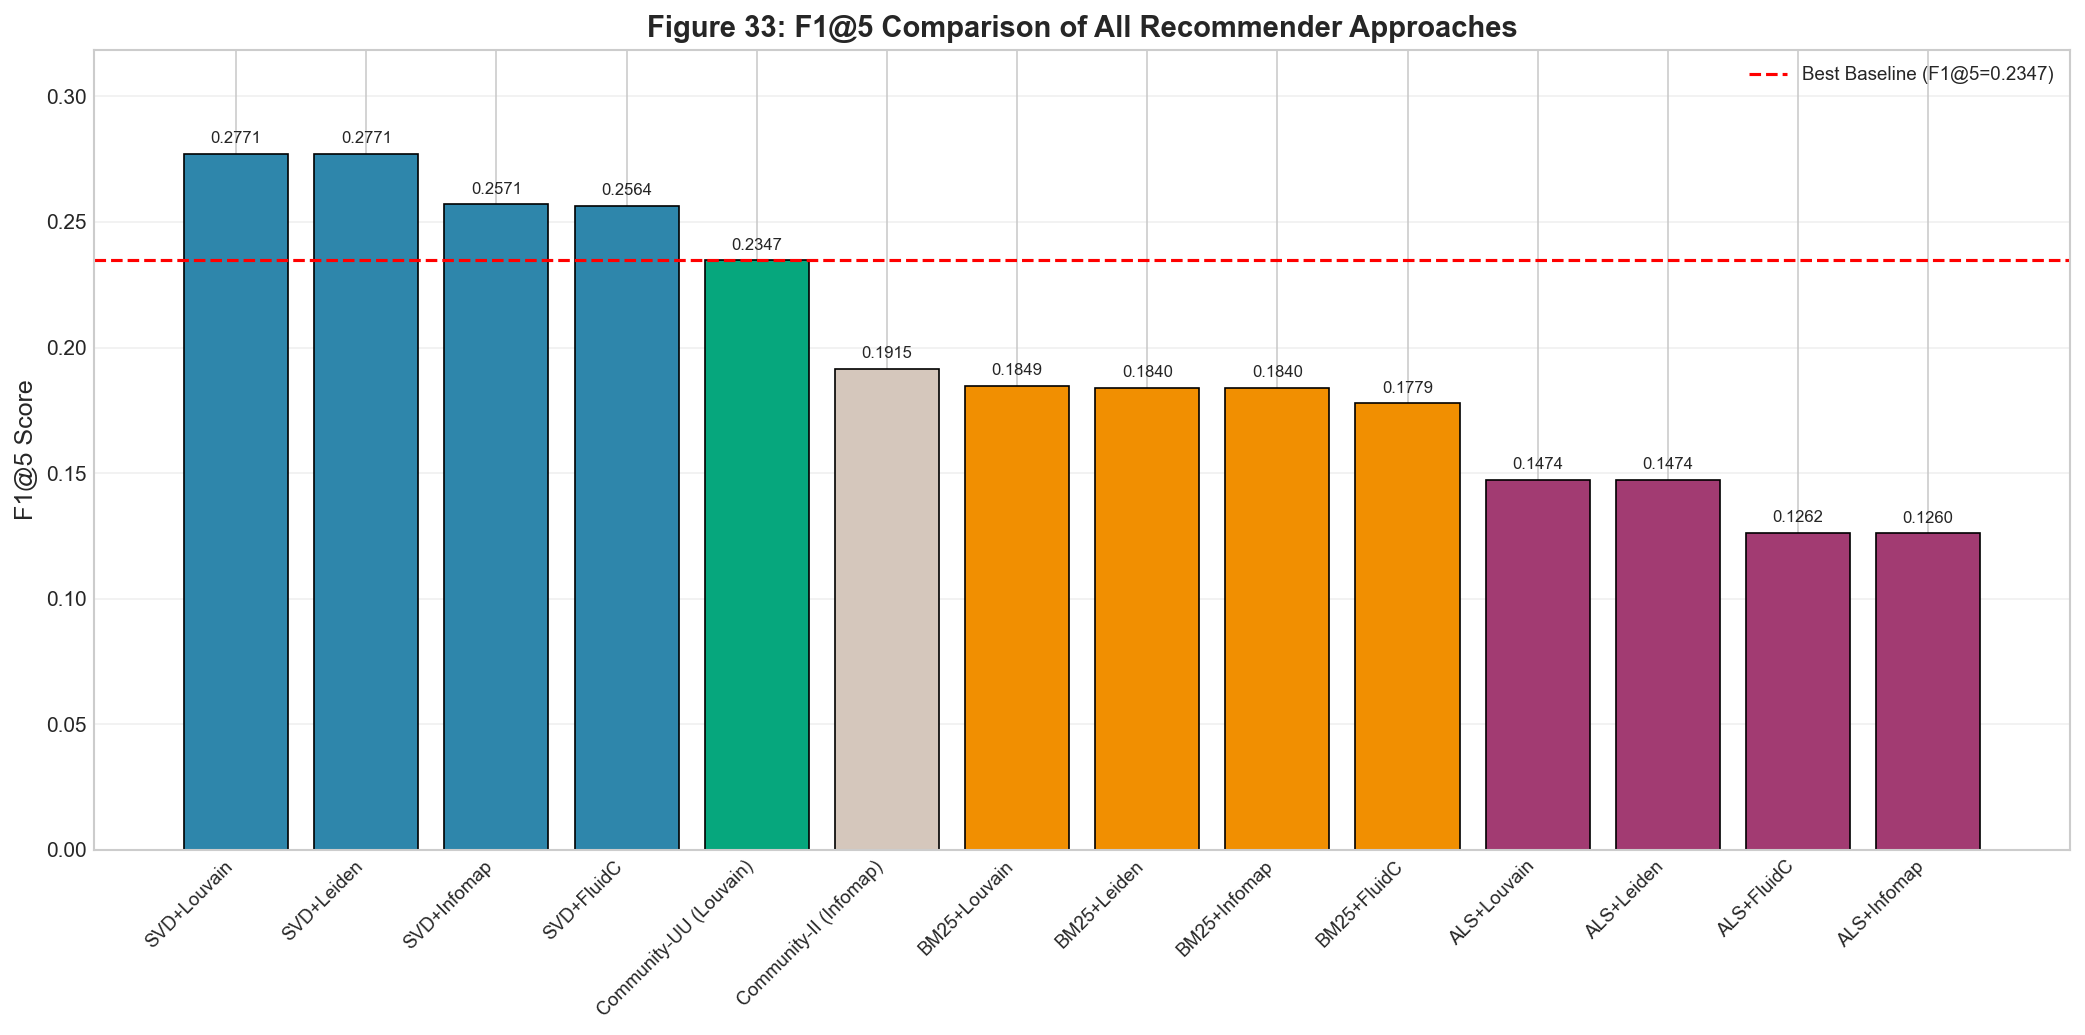

✓ Figure 33 saved



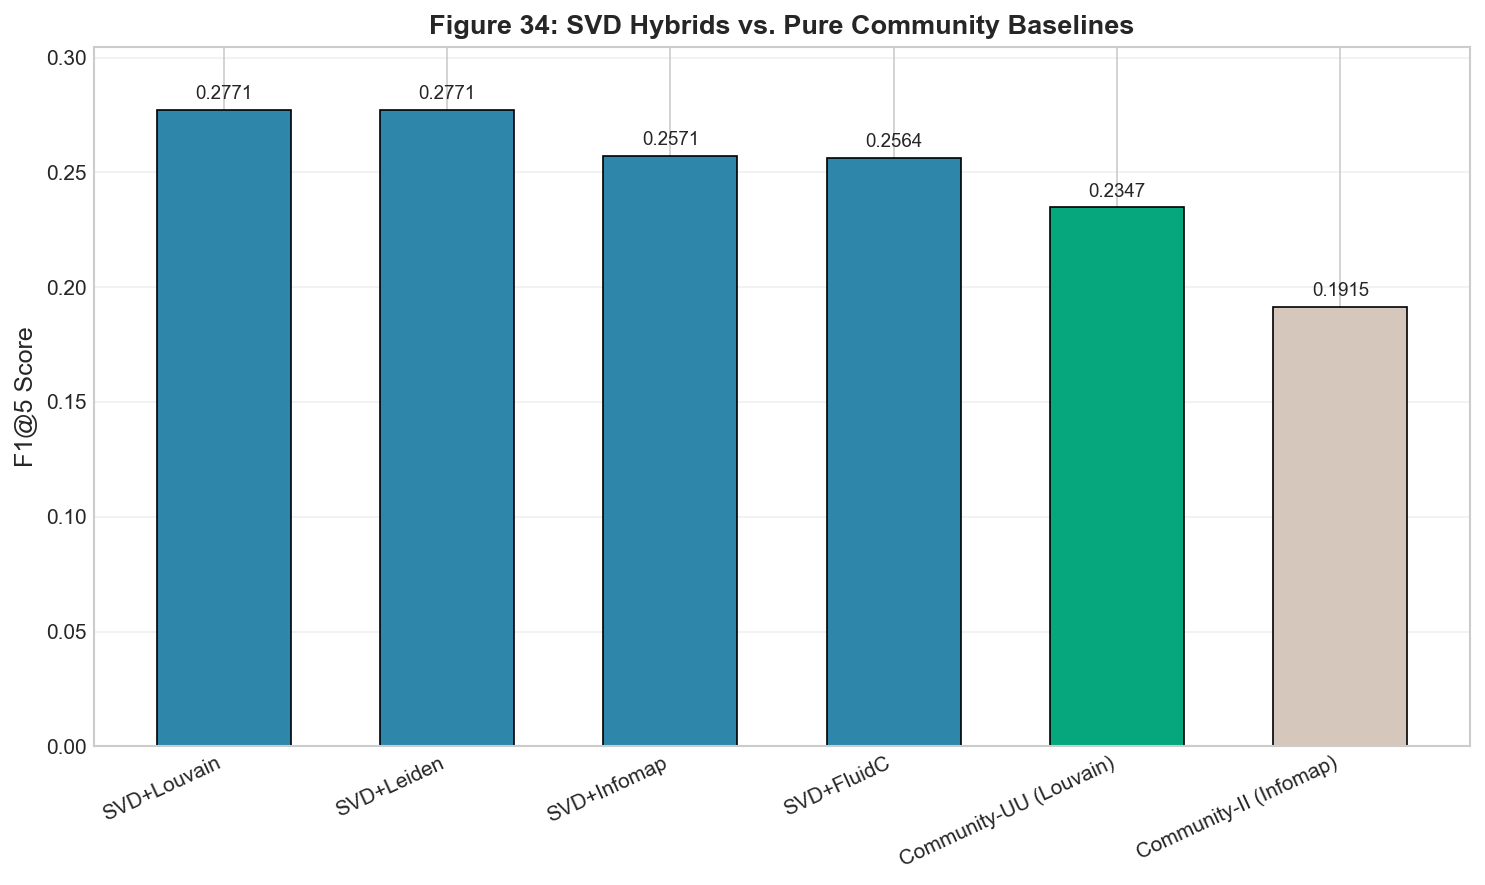

✓ Figure 34 saved



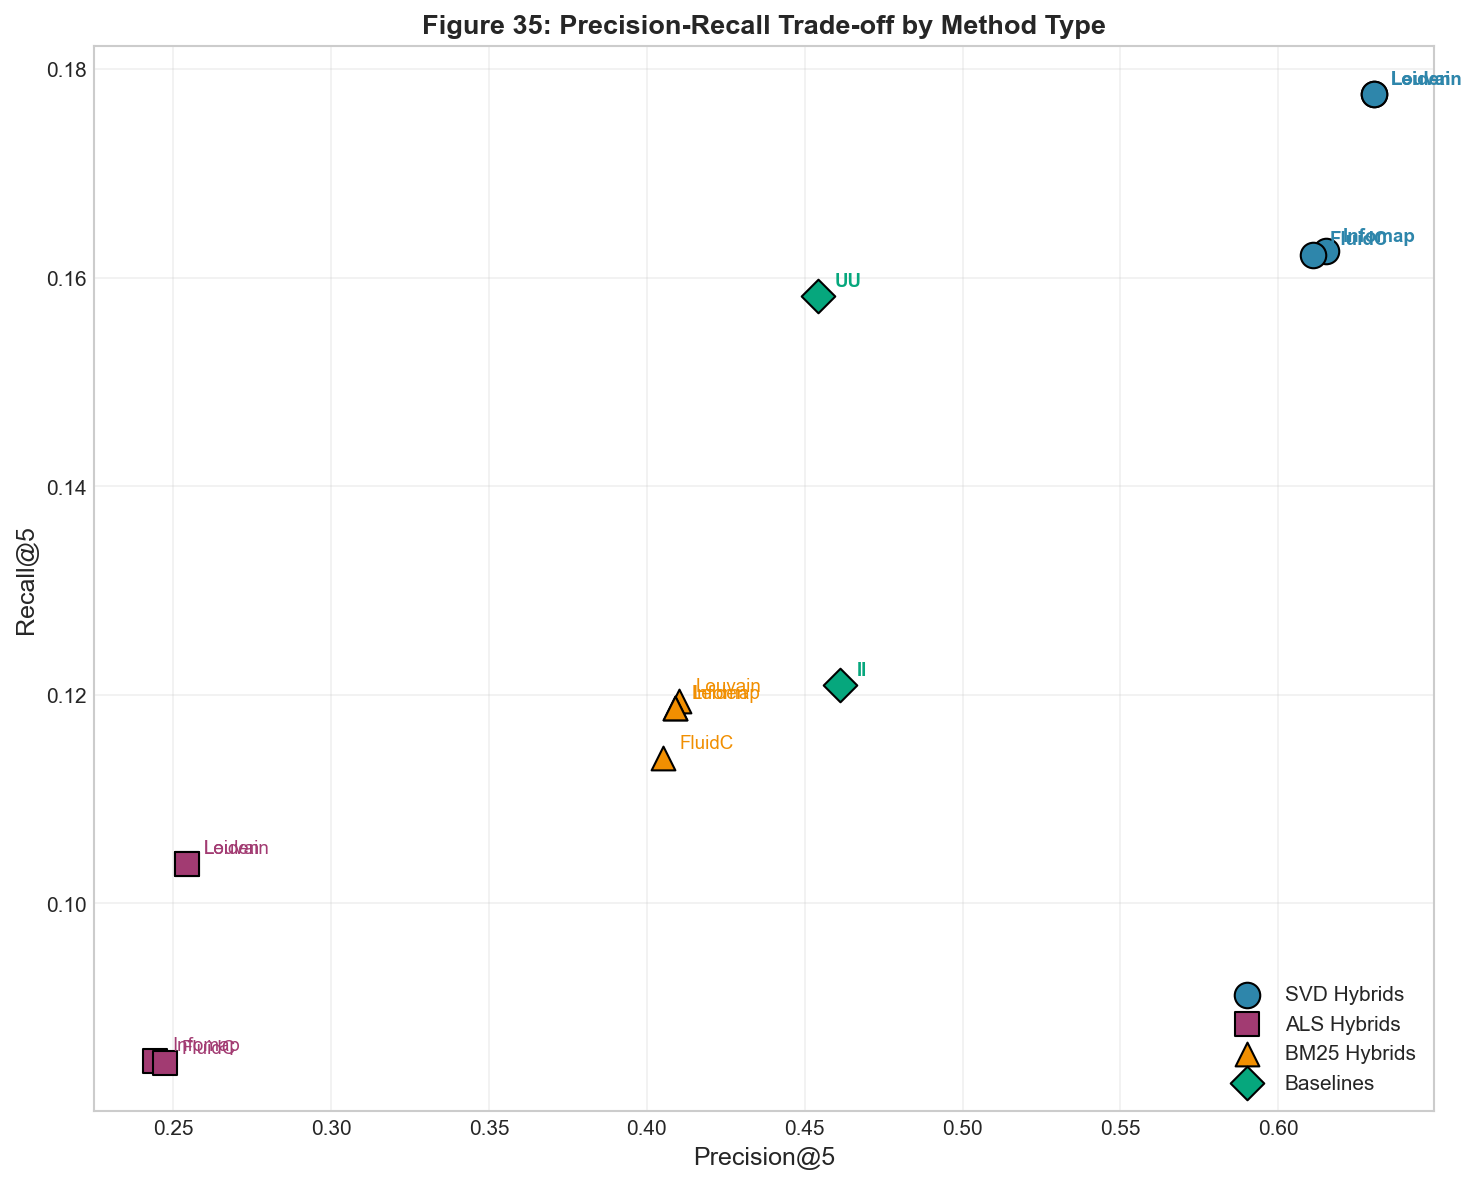

✓ Figure 35 saved



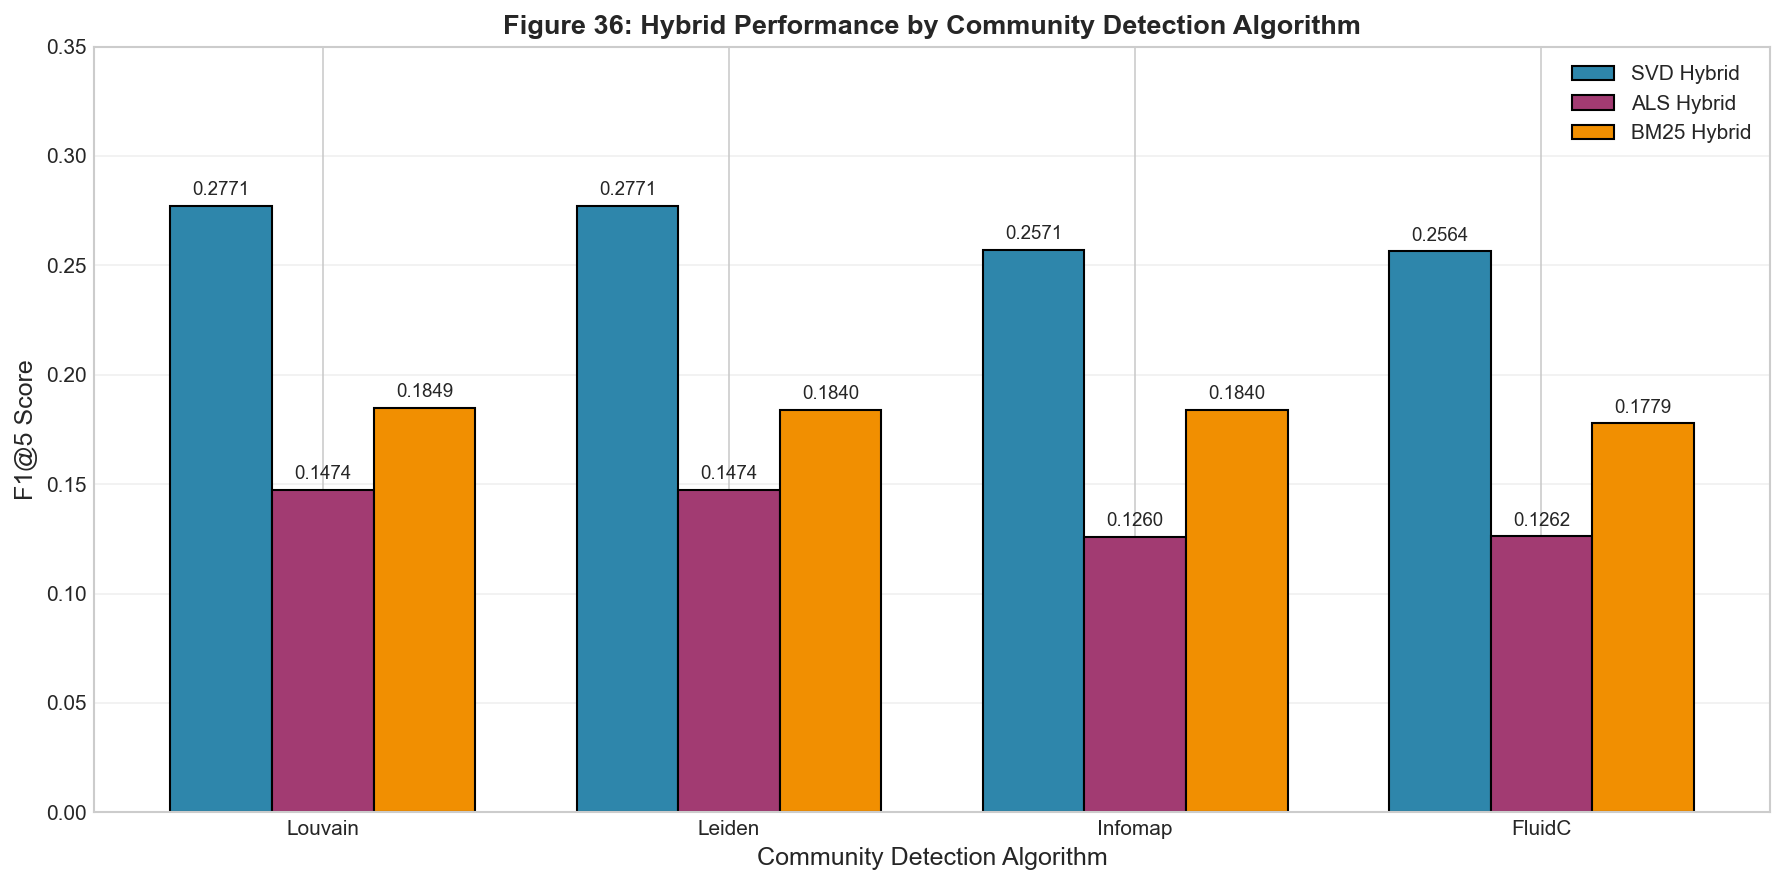

✓ Figure 36 saved



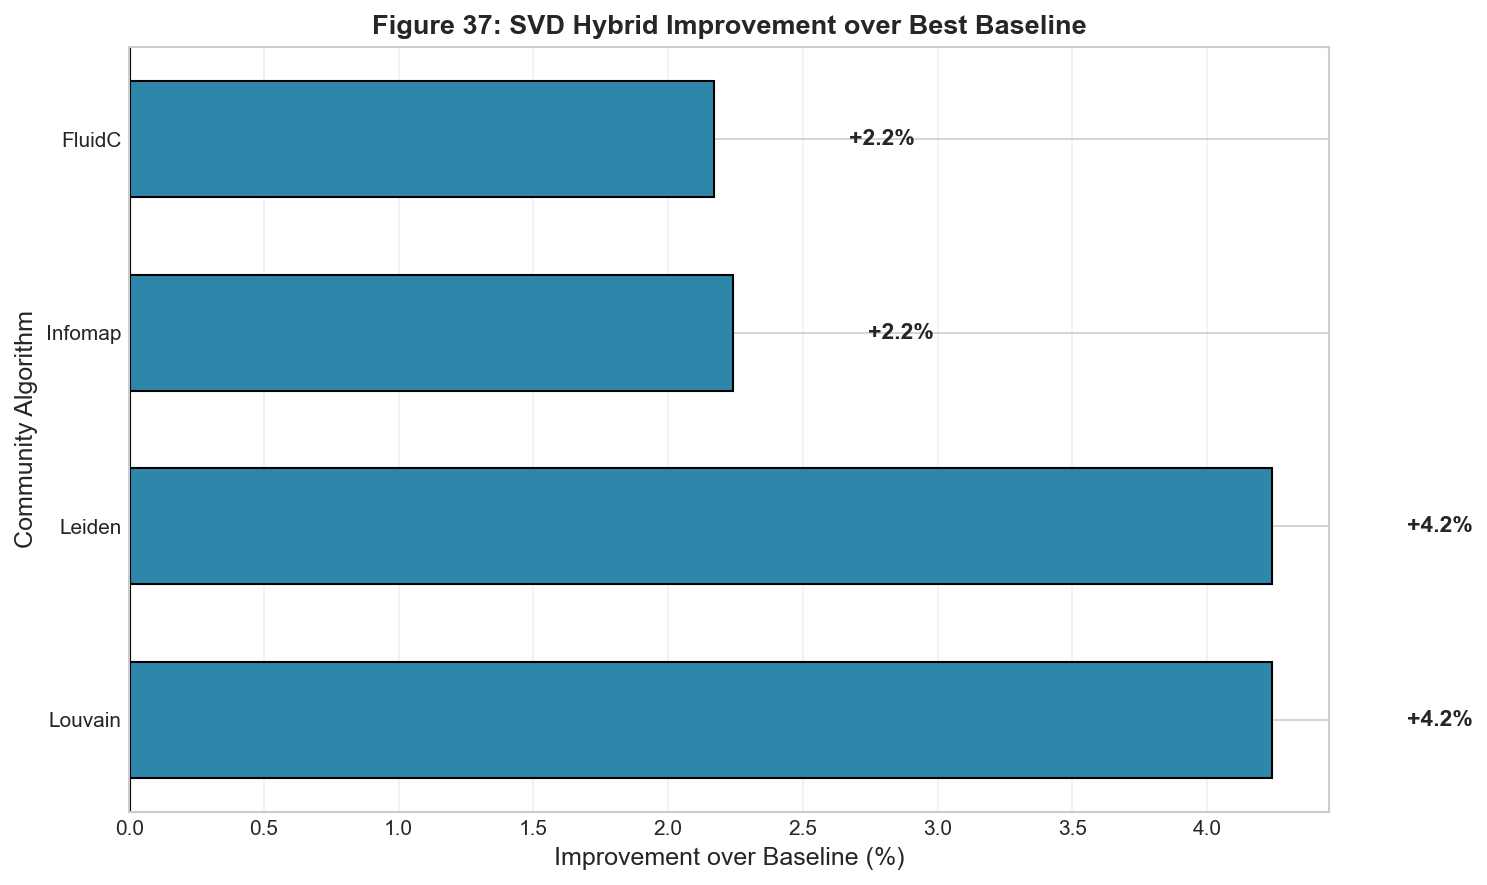

✓ Figure 37 saved


SUMMARY STATISTICS FOR REPORT

📊 BEST PERFORMING METHOD:
   → SVD+Louvain
   → F1@5 = 0.2771
   → Precision@5 = 0.6302
   → Recall@5 = 0.1776
   → Improvement over baseline: +18.1%

📊 SVD HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):
   → SVD+Louvain: F1@5=0.2771 (Δ = +18.1%)
   → SVD+Leiden: F1@5=0.2771 (Δ = +18.1%)
   → SVD+Infomap: F1@5=0.2571 (Δ = +9.5%)
   → SVD+FluidC: F1@5=0.2564 (Δ = +9.2%)

📊 ALS HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):
   → ALS+Louvain: F1@5=0.1474 (Δ = -37.2%)
   → ALS+Leiden: F1@5=0.1474 (Δ = -37.2%)
   → ALS+Infomap: F1@5=0.1260 (Δ = -46.3%)
   → ALS+FluidC: F1@5=0.1262 (Δ = -46.2%)

📊 BM25 HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):
   → BM25+Louvain: F1@5=0.1849 (Δ = -21.2%)
   → BM25+Leiden: F1@5=0.1840 (Δ = -21.6%)
   → BM25+Infomap: F1@5=0.1840 (Δ = -21.6%)
   → BM25+FluidC: F1@5=0.1779 (Δ = -24.2%)

✅ All figures generated successfully!
📁 Files: figure33_*.pdf/png, figure34_*.pdf/png, figure35_*.pdf/png, figure36_*.pdf/png,

In [2]:
# ============================================================
# CORRECTED CODE - MATCHING YOUR ACTUAL COLUMN NAMES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style for report figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

# Load your saved results
df_results = pd.read_csv('hybrid_community_results.csv', index_col=0)

# Rename columns to match what the code expects (if needed)
# Your actual columns are: Precision@5, Recall@5, F1@5, Precision@10, Recall@10, F1@10
# This matches what we need!

print("=== Loaded Results ===\n")
print(df_results[['Precision@5', 'Recall@5', 'F1@5']].to_string())
print("\n" + "="*60 + "\n")

# ============================================================
# FIGURE 33: Bar Chart - F1@5 Comparison (All Methods)
# ============================================================

fig1, ax1 = plt.subplots(figsize=(14, 7))

# Sort by F1@5 descending
df_sorted = df_results.sort_values('F1@5', ascending=False)

colors = []
for method in df_sorted.index:
    if 'SVD+' in method:
        colors.append('#2E86AB')  # Blue for SVD hybrids
    elif 'ALS+' in method:
        colors.append('#A23B72')  # Purple for ALS hybrids
    elif 'BM25+' in method:
        colors.append('#F18F01')  # Orange for BM25 hybrids
    elif 'Community-UU' in method:
        colors.append('#06A77D')  # Green for User-User baseline
    else:
        colors.append('#D5C7BC')  # Light brown for Item-Item baseline

bars = ax1.bar(range(len(df_sorted)), df_sorted['F1@5'].values, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_xticks(range(len(df_sorted)))
ax1.set_xticklabels(df_sorted.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('F1@5 Score', fontsize=12)
ax1.set_title('Figure 33: F1@5 Comparison of All Recommender Approaches', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(df_sorted['F1@5']) * 1.15)

# Add baseline reference line
baseline_f1 = df_results.loc['Community-UU (Louvain)', 'F1@5']
ax1.axhline(y=baseline_f1, color='red', linestyle='--', linewidth=1.5, 
            label=f"Best Baseline (F1@5={baseline_f1:.4f})")

# Add value labels on bars
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    ax1.text(i, row['F1@5'] + 0.003, f"{row['F1@5']:.4f}", ha='center', va='bottom', fontsize=8)

ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure33_f1_comparison.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure33_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 33 saved\n")

# ============================================================
# FIGURE 34: SVD Hybrids vs Baselines
# ============================================================

fig2, ax2 = plt.subplots(figsize=(10, 6))

# Extract methods
svd_methods = ['SVD+Louvain', 'SVD+Leiden', 'SVD+Infomap', 'SVD+FluidC']
baseline_methods = ['Community-UU (Louvain)', 'Community-II (Infomap)']
selected_methods = svd_methods + baseline_methods
df_selected = df_results.loc[selected_methods].copy()

x = np.arange(len(selected_methods))
width = 0.6

colors_bar2 = ['#2E86AB'] * 4 + ['#06A77D', '#D5C7BC']
bars2 = ax2.bar(x, df_selected['F1@5'], width, color=colors_bar2, edgecolor='black', linewidth=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(selected_methods, rotation=25, ha='right', fontsize=10)
ax2.set_ylabel('F1@5 Score', fontsize=12)
ax2.set_title('Figure 34: SVD Hybrids vs. Pure Community Baselines', fontweight='bold', fontsize=13)
ax2.set_ylim(0, max(df_selected['F1@5']) * 1.1)

# Add value labels
for i, (idx, row) in enumerate(df_selected.iterrows()):
    ax2.text(i, row['F1@5'] + 0.003, f"{row['F1@5']:.4f}", ha='center', va='bottom', fontsize=9)

ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure34_svd_hybrids.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure34_svd_hybrids.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 34 saved\n")

# ============================================================
# FIGURE 35: Precision-Recall Scatter Plot
# ============================================================

fig3, ax3 = plt.subplots(figsize=(10, 8))

# Categorize methods
svd_methods_all = [m for m in df_results.index if 'SVD+' in m]
als_methods_all = [m for m in df_results.index if 'ALS+' in m]
bm25_methods_all = [m for m in df_results.index if 'BM25+' in m]
baseline_methods_all = [m for m in df_results.index if 'Community' in m]

# Plot SVD hybrids
for method in svd_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    ax3.scatter(p5, r5, c='#2E86AB', marker='o', s=150, edgecolor='black', linewidth=1, 
                label='SVD Hybrids' if method == svd_methods_all[0] else "")
    ax3.annotate(method.replace('SVD+', ''), (p5, r5), xytext=(8, 5), textcoords='offset points', 
                fontsize=9, fontweight='bold', color='#2E86AB')

# Plot ALS hybrids
for method in als_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    ax3.scatter(p5, r5, c='#A23B72', marker='s', s=130, edgecolor='black', linewidth=1,
                label='ALS Hybrids' if method == als_methods_all[0] else "")
    ax3.annotate(method.replace('ALS+', ''), (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, color='#A23B72')

# Plot BM25 hybrids
for method in bm25_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    ax3.scatter(p5, r5, c='#F18F01', marker='^', s=130, edgecolor='black', linewidth=1,
                label='BM25 Hybrids' if method == bm25_methods_all[0] else "")
    ax3.annotate(method.replace('BM25+', ''), (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, color='#F18F01')

# Plot Baselines
for method in baseline_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    label = 'Baselines' if method == baseline_methods_all[0] else ""
    ax3.scatter(p5, r5, c='#06A77D', marker='D', s=130, edgecolor='black', linewidth=1, label=label)
    ax3.annotate('UU' if 'UU' in method else 'II', (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color='#06A77D')

ax3.set_xlabel('Precision@5', fontsize=12)
ax3.set_ylabel('Recall@5', fontsize=12)
ax3.set_title('Figure 35: Precision-Recall Trade-off by Method Type', fontweight='bold', fontsize=13)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('figure35_pr_scatter.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure35_pr_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 35 saved\n")

# ============================================================
# FIGURE 36: Performance by Community Algorithm
# ============================================================

fig4, ax4 = plt.subplots(figsize=(12, 6))

algorithms = ['Louvain', 'Leiden', 'Infomap', 'FluidC']
x4 = np.arange(len(algorithms))
width4 = 0.25

svd_scores = [df_results.loc[f'SVD+{a}', 'F1@5'] for a in algorithms]
als_scores = [df_results.loc[f'ALS+{a}', 'F1@5'] for a in algorithms]
bm25_scores = [df_results.loc[f'BM25+{a}', 'F1@5'] for a in algorithms]

bars_svd = ax4.bar(x4 - width4, svd_scores, width4, label='SVD Hybrid', color='#2E86AB', edgecolor='black')
bars_als = ax4.bar(x4, als_scores, width4, label='ALS Hybrid', color='#A23B72', edgecolor='black')
bars_bm25 = ax4.bar(x4 + width4, bm25_scores, width4, label='BM25 Hybrid', color='#F18F01', edgecolor='black')

ax4.set_xlabel('Community Detection Algorithm', fontsize=12)
ax4.set_ylabel('F1@5 Score', fontsize=12)
ax4.set_title('Figure 36: Hybrid Performance by Community Detection Algorithm', fontweight='bold', fontsize=13)
ax4.set_xticks(x4)
ax4.set_xticklabels(algorithms)
ax4.set_ylim(0, 0.35)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars, scores in [(bars_svd, svd_scores), (bars_als, als_scores), (bars_bm25, bm25_scores)]:
    for bar, score in zip(bars, scores):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
                f'{score:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure36_by_algorithm.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure36_by_algorithm.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 36 saved\n")

# ============================================================
# FIGURE 37: Improvement Over Baseline
# ============================================================

fig5, ax5 = plt.subplots(figsize=(10, 6))

baseline_f1 = df_results.loc['Community-UU (Louvain)', 'F1@5']
svd_methods_only = ['SVD+Louvain', 'SVD+Leiden', 'SVD+Infomap', 'SVD+FluidC']
improvements = [(df_results.loc[m, 'F1@5'] - baseline_f1) * 100 for m in svd_methods_only]
method_names = [m.replace('SVD+', '') for m in svd_methods_only]

colors_imp = ['#2E86AB' if imp > 0 else '#D9534F' for imp in improvements]
bars_imp = ax5.barh(method_names, improvements, color=colors_imp, edgecolor='black', height=0.6)
ax5.axvline(x=0, color='black', linewidth=1.5)
ax5.set_xlabel('Improvement over Baseline (%)', fontsize=12)
ax5.set_ylabel('Community Algorithm', fontsize=12)
ax5.set_title('Figure 37: SVD Hybrid Improvement over Best Baseline', fontweight='bold', fontsize=13)

for bar, imp, name in zip(bars_imp, improvements, method_names):
    ax5.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'+{imp:.1f}%', va='center', ha='left', fontsize=11, fontweight='bold')

ax5.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figure37_improvement.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure37_improvement.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 37 saved\n")

# ============================================================
# PRINT SUMMARY STATISTICS
# ============================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS FOR REPORT")
print("="*70)

best_overall = df_results['F1@5'].idxmax()
best_f1 = df_results.loc[best_overall, 'F1@5']
best_baseline = 'Community-UU (Louvain)'
baseline_f1_val = df_results.loc[best_baseline, 'F1@5']
improvement_pct = ((best_f1 - baseline_f1_val) / baseline_f1_val) * 100

print(f"\n📊 BEST PERFORMING METHOD:")
print(f"   → {best_overall}")
print(f"   → F1@5 = {best_f1:.4f}")
print(f"   → Precision@5 = {df_results.loc[best_overall, 'Precision@5']:.4f}")
print(f"   → Recall@5 = {df_results.loc[best_overall, 'Recall@5']:.4f}")
print(f"   → Improvement over baseline: +{improvement_pct:.1f}%\n")

print("📊 SVD HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):")
for method in svd_methods_only:
    f1 = df_results.loc[method, 'F1@5']
    imp = ((f1 - baseline_f1_val) / baseline_f1_val) * 100
    print(f"   → {method}: F1@5={f1:.4f} (Δ = +{imp:.1f}%)")

print("\n📊 ALS HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):")
for method in als_methods_all:
    f1 = df_results.loc[method, 'F1@5']
    imp = ((f1 - baseline_f1_val) / baseline_f1_val) * 100
    print(f"   → {method}: F1@5={f1:.4f} (Δ = {imp:+.1f}%)")

print("\n📊 BM25 HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):")
for method in bm25_methods_all:
    f1 = df_results.loc[method, 'F1@5']
    imp = ((f1 - baseline_f1_val) / baseline_f1_val) * 100
    print(f"   → {method}: F1@5={f1:.4f} (Δ = {imp:+.1f}%)")

print("\n" + "="*70)
print("✅ All figures generated successfully!")
print("📁 Files: figure33_*.pdf/png, figure34_*.pdf/png, figure35_*.pdf/png, figure36_*.pdf/png, figure37_*.pdf/png")

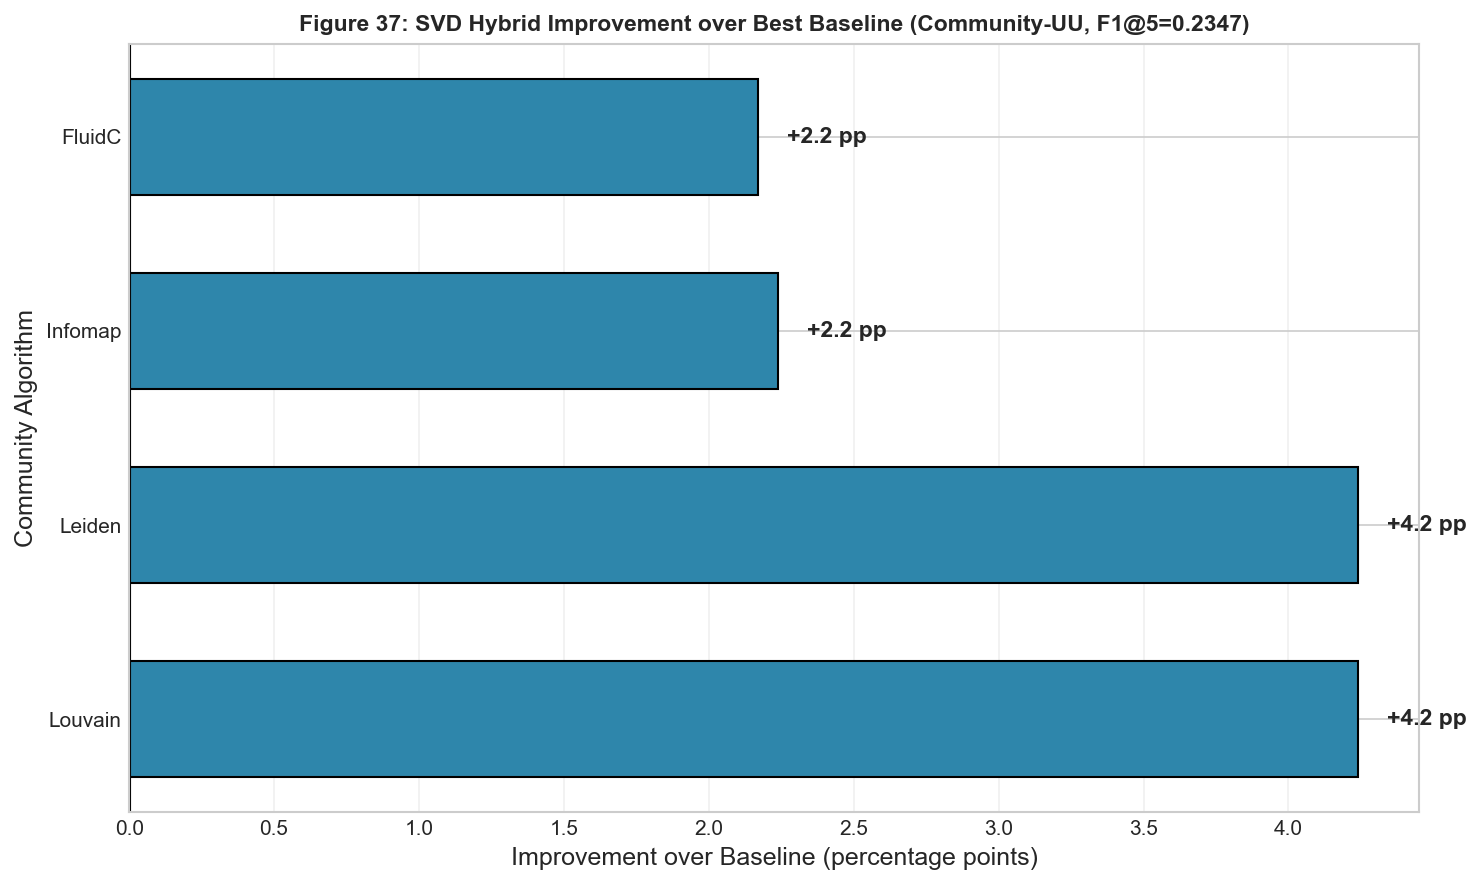

✓ Figure 37 saved (CORRECTED: shows +4.2 pp for Louvain/Leiden, +2.2 pp for Infomap/FluidC)



In [3]:
# ============================================================
# FIGURE 37: Improvement Over Baseline (CORRECTED)
# ============================================================

fig5, ax5 = plt.subplots(figsize=(10, 6))

baseline_f1 = df_results.loc['Community-UU (Louvain)', 'F1@5']
svd_methods_only = ['SVD+Louvain', 'SVD+Leiden', 'SVD+Infomap', 'SVD+FluidC']
# Calculate ABSOLUTE improvement (not percentage)
improvements_absolute = [(df_results.loc[m, 'F1@5'] - baseline_f1) * 100 for m in svd_methods_only]
method_names = [m.replace('SVD+', '') for m in svd_methods_only]

# Values: Louvain=4.24, Leiden=4.24, Infomap=2.24, FluidC=2.17
# Round to 1 decimal for cleaner display
improvements_display = [round(imp, 1) for imp in improvements_absolute]

colors_imp = ['#2E86AB' if imp > 0 else '#D9534F' for imp in improvements_absolute]
bars_imp = ax5.barh(method_names, improvements_absolute, color=colors_imp, edgecolor='black', height=0.6)
ax5.axvline(x=0, color='black', linewidth=1.5)
ax5.set_xlabel('Improvement over Baseline (percentage points)', fontsize=12)
ax5.set_ylabel('Community Algorithm', fontsize=12)
ax5.set_title('Figure 37: SVD Hybrid Improvement over Best Baseline (Community-UU, F1@5=0.2347)', 
              fontweight='bold', fontsize=11)

# Add value labels with + sign and one decimal
for bar, imp, name in zip(bars_imp, improvements_absolute, method_names):
    ax5.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'+{imp:.1f} pp', va='center', ha='left', fontsize=11, fontweight='bold')

ax5.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figure37_improvement.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure37_improvement.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 37 saved (CORRECTED: shows +4.2 pp for Louvain/Leiden, +2.2 pp for Infomap/FluidC)\n")

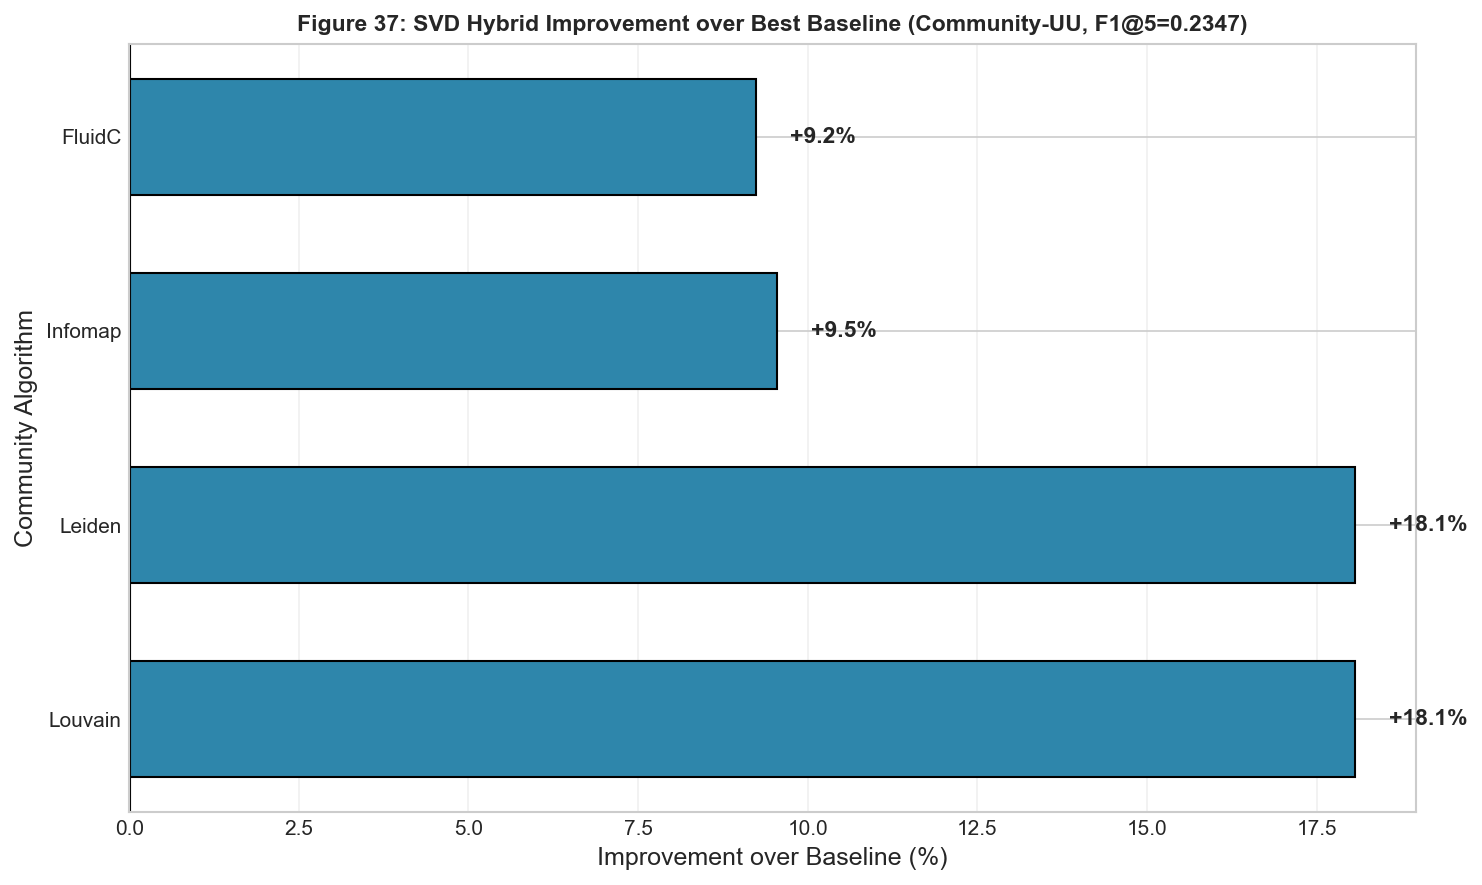

✓ Figure 37 saved (shows +18.1% for Louvain/Leiden, +9.5% for Infomap, +9.2% for FluidC)



In [4]:
# ============================================================
# FIGURE 37: Improvement Over Baseline (PERCENTAGE)
# ============================================================

fig5, ax5 = plt.subplots(figsize=(10, 6))

baseline_f1 = df_results.loc['Community-UU (Louvain)', 'F1@5']
svd_methods_only = ['SVD+Louvain', 'SVD+Leiden', 'SVD+Infomap', 'SVD+FluidC']

# Calculate RELATIVE PERCENTAGE improvement
improvements_pct = [((df_results.loc[m, 'F1@5'] - baseline_f1) / baseline_f1) * 100 for m in svd_methods_only]
method_names = [m.replace('SVD+', '') for m in svd_methods_only]

# Values: Louvain=18.1%, Leiden=18.1%, Infomap=9.5%, FluidC=9.2%
improvements_display = [round(imp, 1) for imp in improvements_pct]

colors_imp = ['#2E86AB' if imp > 0 else '#D9534F' for imp in improvements_pct]
bars_imp = ax5.barh(method_names, improvements_pct, color=colors_imp, edgecolor='black', height=0.6)
ax5.axvline(x=0, color='black', linewidth=1.5)
ax5.set_xlabel('Improvement over Baseline (%)', fontsize=12)
ax5.set_ylabel('Community Algorithm', fontsize=12)
ax5.set_title('Figure 37: SVD Hybrid Improvement over Best Baseline (Community-UU, F1@5=0.2347)', 
              fontweight='bold', fontsize=11)

# Add value labels with % sign
for bar, imp, name in zip(bars_imp, improvements_pct, method_names):
    ax5.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'+{imp:.1f}%', va='center', ha='left', fontsize=11, fontweight='bold')

ax5.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figure37_improvement.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure37_improvement.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 37 saved (shows +18.1% for Louvain/Leiden, +9.5% for Infomap, +9.2% for FluidC)\n")